# EDA - PHEME Rumour Detection Dataset
**Source**: *Zero-Shot Rumor Detection with Propagation Structure via Prompt Learning*  
**File**: `PHEME-rumourdetection.csv` (62,445 tweets)  
**Label**: `is_rumor` (0 = not rumour, 1 = rumour)  
**Topics**: Charlie Hebdo attack, Ferguson unrest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

FIGURES_PATH = '../../results/figures/'

## 1. Load Data

In [2]:
df = pd.read_csv('../../data/raw/PHEME-rumourdetection.csv')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Columns: {df.columns.tolist()}')

Shape: 62,445 rows x 4 cols
Columns: ['text', 'is_rumor', 'user.handle', 'topic']


In [3]:
df.head(3)

,text,is_rumor,user.handle,topic
0,Charlie Hebdo became well known for publishing...,0.0,BBCDanielS,charliehebdo
1,"Now 10 dead in a shooting there today RT ""@BBC...",0.0,robbylevy,charliehebdo
2,@BBCDanielS @BBCWorld I'm guessing this is bei...,0.0,ModerateInAll,charliehebdo


In [4]:
print('Missing values:')
print(df.isnull().sum())

# Normalize label
df['label'] = df['is_rumor'].map({0.0: 'not_rumour', 1.0: 'rumour'})
df['topic'] = df['topic'].fillna('unknown')
print('\nLabel distribution:')
print(df['label'].value_counts())
print('\nTopic distribution:')
print(df['topic'].value_counts())

Missing values:
text               0
is_rumor           2
user.handle        2
topic          12777
dtype: int64

Label distribution:
label
not_rumour    48619
rumour        13824
Name: count, dtype: int64

Topic distribution:
topic
charliehebdo    25491
ferguson        24177
unknown         12777
Name: count, dtype: int64


## 2. Label & Topic Analysis

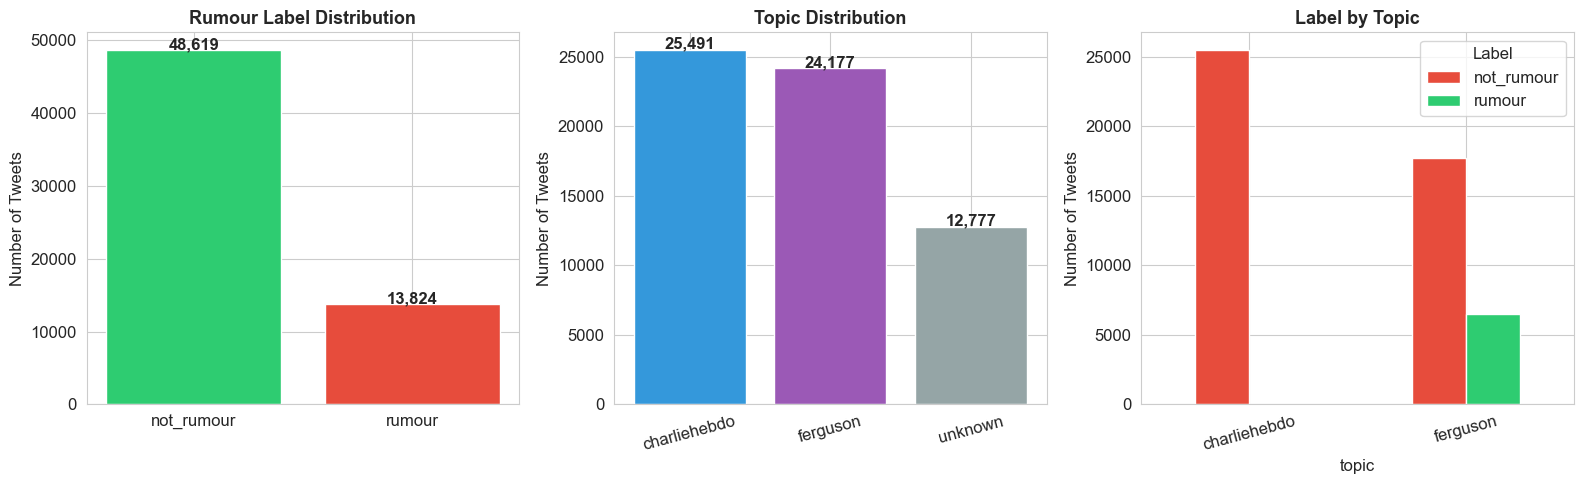

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Label distribution
counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['#2ecc71' if x == 'not_rumour' else '#e74c3c' for x in counts.index],
            edgecolor='white')
axes[0].set_title('Rumour Label Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Tweets')
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', fontweight='bold')

# Topic distribution
topic_counts = df['topic'].value_counts()
topic_colors = {'charliehebdo': '#3498db', 'ferguson': '#9b59b6', 'unknown': '#95a5a6'}
axes[1].bar(topic_counts.index, topic_counts.values,
            color=[topic_colors.get(x, '#bdc3c7') for x in topic_counts.index],
            edgecolor='white')
axes[1].set_title('Topic Distribution', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Tweets')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(axes[1].patches, topic_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', fontweight='bold')

# Label x Topic
cross = df[df['topic'] != 'unknown'].groupby(['topic', 'label']).size().unstack(fill_value=0)
cross.plot(kind='bar', ax=axes[2],
           color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[2].set_title('Label by Topic', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Number of Tweets')
axes[2].tick_params(axis='x', rotation=15)
axes[2].legend(title='Label')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}pheme_01_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Tweet Length Analysis

In [6]:
df['tweet_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print('Tweet length stats by label:')
print(df.groupby('label')[['tweet_length', 'word_count']].describe().round(1).to_string())

Tweet length stats by label:
           tweet_length                                             word_count                                        
                  count  mean   std  min   25%    50%    75%    max      count  mean  std  min   25%   50%   75%   max
label                                                                                                                 
not_rumour      48619.0  99.2  37.0  4.0  69.0  109.0  134.0  152.0    48619.0  14.5  6.4  1.0   9.0  15.0  20.0  34.0
rumour          13824.0  98.3  37.3  3.0  68.0  107.0  133.0  187.0    13824.0  14.6  6.4  1.0  10.0  15.0  20.0  32.0


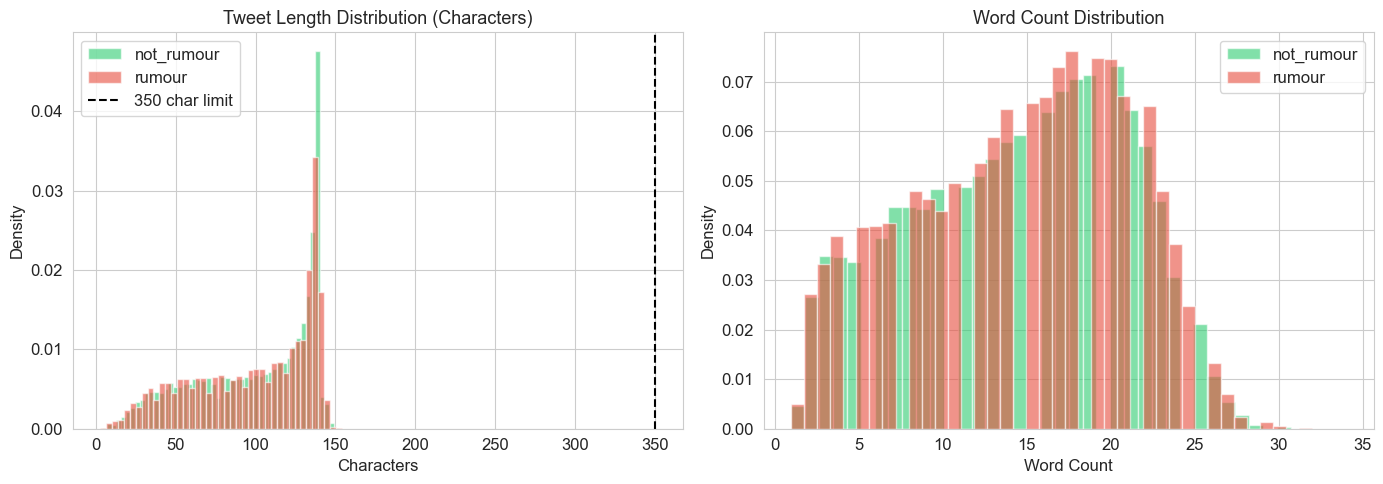

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [('not_rumour', '#2ecc71'), ('rumour', '#e74c3c')]:
    subset = df[df['label'] == label]
    axes[0].hist(subset['tweet_length'], bins=50, alpha=0.6, label=label, color=color, density=True)
    axes[1].hist(subset['word_count'].clip(0, 80), bins=40, alpha=0.6, label=label, color=color, density=True)

axes[0].set_title('Tweet Length Distribution (Characters)', fontsize=13)
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Density')
axes[0].axvline(350, color='black', linestyle='--', label='350 char limit')
axes[0].legend()

axes[1].set_title('Word Count Distribution', fontsize=13)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}pheme_02_tweet_length.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Top Words

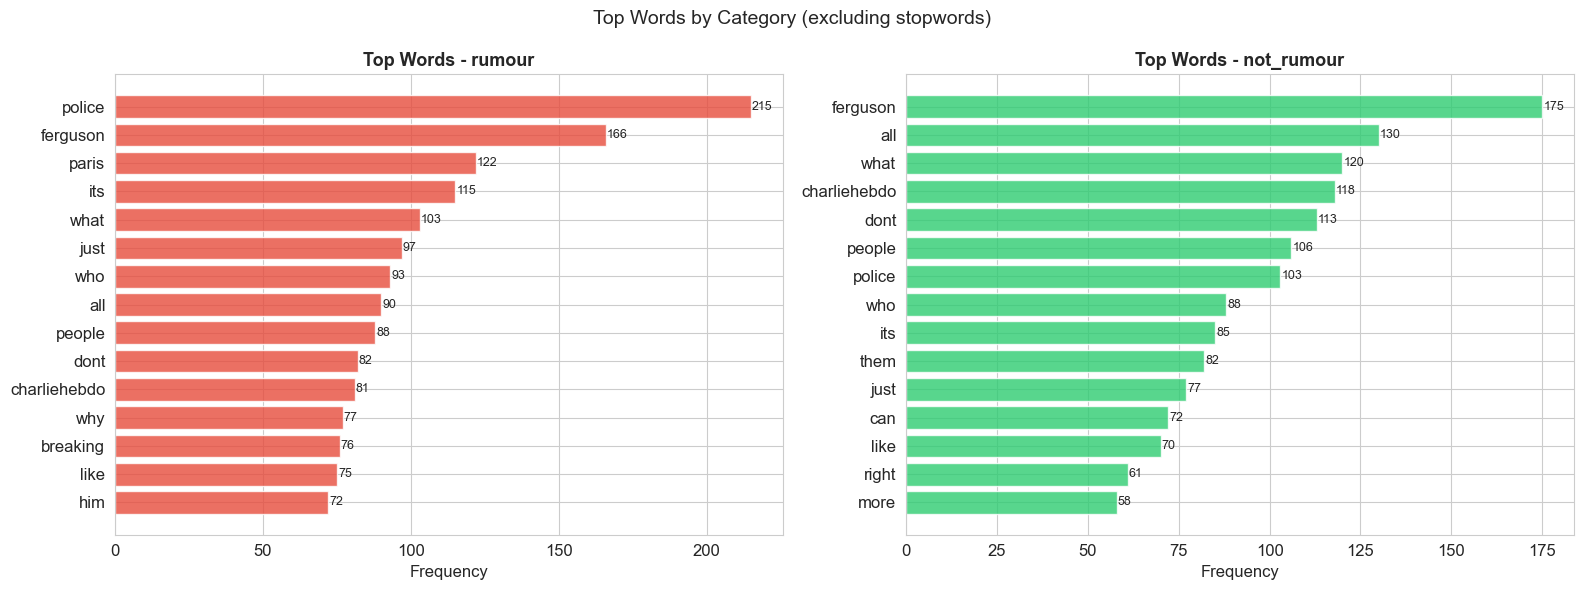

In [8]:
STOPWORDS = set(['the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to',
                  'for', 'of', 'with', 'is', 'it', 'this', 'that', 'are', 'was',
                  'were', 'be', 'been', 'have', 'has', 'had', 'do', 'does', 'did',
                  'will', 'would', 'could', 'should', 'may', 'might', 'i', 'you',
                  'he', 'she', 'we', 'they', 'my', 'your', 'his', 'her', 'our',
                  'their', 'not', 'no', 'so', 'if', 'as', 'by', 'from', 'up',
                  'about', 'into', 'through', 'rt', 'amp'])

def get_top_words(texts, n=15):
    words = []
    for text in texts:
        t = str(text).lower()
        t = re.sub(r'http\S+|@\w+', '', t)
        t = re.sub(r'#(\w+)', r'\1', t)
        t = re.sub(r'[^a-z\s]', '', t)
        words.extend([w for w in t.split() if w not in STOPWORDS and len(w) > 2])
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, label, color in [(axes[0], 'rumour', '#e74c3c'), (axes[1], 'not_rumour', '#2ecc71')]:
    sample = df[df['label'] == label]['text'].sample(min(2000, (df['label'] == label).sum()), random_state=42)
    top = get_top_words(sample, n=15)
    words, counts = zip(*top)
    ax.barh(words[::-1], counts[::-1], color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'Top Words - {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')
    for bar, val in zip(ax.patches, counts[::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)

plt.suptitle('Top Words by Category (excluding stopwords)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}pheme_03_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Top Words by Topic

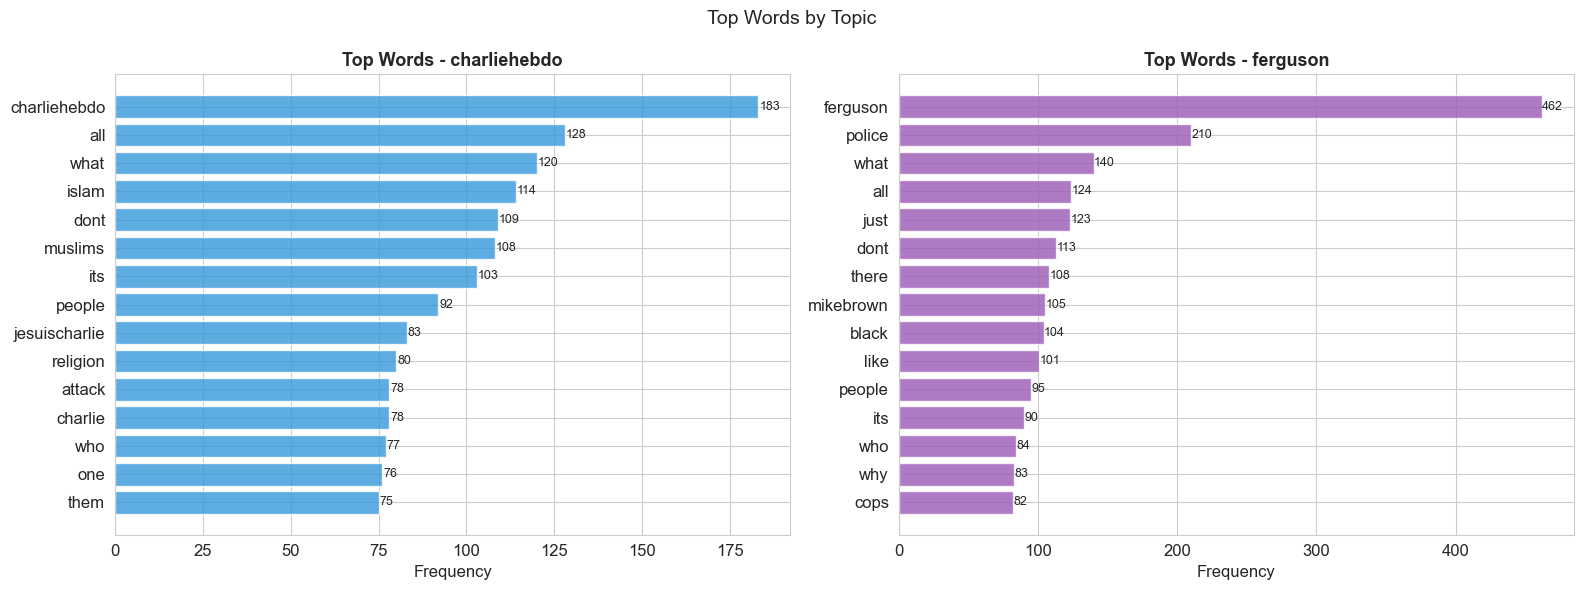

In [9]:
known_topics = df[df['topic'] != 'unknown']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

topic_colors_map = {'charliehebdo': '#3498db', 'ferguson': '#9b59b6'}
for ax, topic in zip(axes, ['charliehebdo', 'ferguson']):
    sample = known_topics[known_topics['topic'] == topic]['text'].sample(
        min(2000, (known_topics['topic'] == topic).sum()), random_state=42)
    top = get_top_words(sample, n=15)
    words, counts = zip(*top)
    ax.barh(words[::-1], counts[::-1], color=topic_colors_map[topic], alpha=0.8, edgecolor='white')
    ax.set_title(f'Top Words - {topic}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')
    for bar, val in zip(ax.patches, counts[::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)

plt.suptitle('Top Words by Topic', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}pheme_04_top_words_by_topic.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. t-SNE Visualization

Running TF-IDF...
Running t-SNE (~30 sec)...


  File "C:\Users\yoni1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Done.


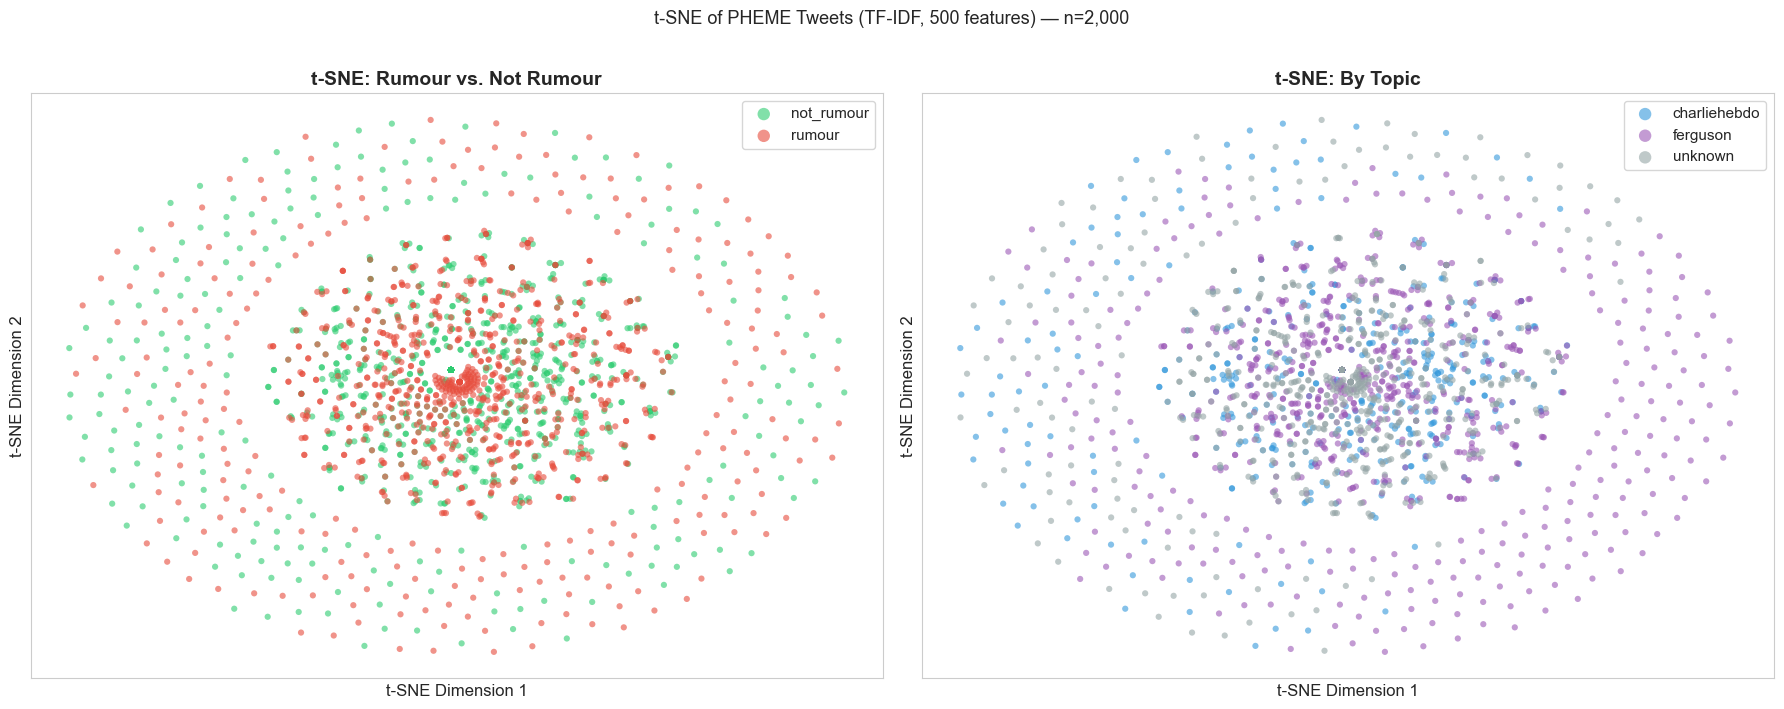

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

# Sample balanced subset
rumour_s = df[df['label'] == 'rumour'].sample(1000, random_state=42)
not_rumour_s = df[df['label'] == 'not_rumour'].sample(1000, random_state=42)
tsne_df = pd.concat([rumour_s, not_rumour_s], ignore_index=True)

def clean_for_tsne(text):
    t = str(text).lower()
    t = re.sub(r'http\S+|@\w+', '', t)
    t = re.sub(r'#(\w+)', r'\1', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

tsne_df['clean'] = tsne_df['text'].apply(clean_for_tsne)

print('Running TF-IDF...')
vectorizer = TfidfVectorizer(max_features=500, min_df=2, stop_words='english')
X = vectorizer.fit_transform(tsne_df['clean']).toarray()

print('Running t-SNE (~30 sec)...')
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_2d = tsne.fit_transform(X)

tsne_df['tsne_x'] = X_2d[:, 0]
tsne_df['tsne_y'] = X_2d[:, 1]
print('Done.')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: by label
for label, color in [('not_rumour', '#2ecc71'), ('rumour', '#e74c3c')]:
    mask = tsne_df['label'] == label
    axes[0].scatter(tsne_df.loc[mask, 'tsne_x'], tsne_df.loc[mask, 'tsne_y'],
                    c=color, label=label, alpha=0.6, s=20, edgecolors='none')
axes[0].set_title('t-SNE: Rumour vs. Not Rumour', fontsize=14, fontweight='bold')
axes[0].set_xlabel('t-SNE Dimension 1')
axes[0].set_ylabel('t-SNE Dimension 2')
axes[0].legend(markerscale=2, fontsize=11)
axes[0].set_xticks([]); axes[0].set_yticks([])

# Plot 2: by topic
topic_colors = {'charliehebdo': '#3498db', 'ferguson': '#9b59b6', 'unknown': '#95a5a6'}
for topic, color in topic_colors.items():
    mask = tsne_df['topic'] == topic
    if mask.sum() == 0: continue
    axes[1].scatter(tsne_df.loc[mask, 'tsne_x'], tsne_df.loc[mask, 'tsne_y'],
                    c=color, label=topic, alpha=0.6, s=20, edgecolors='none')
axes[1].set_title('t-SNE: By Topic', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
axes[1].legend(markerscale=2, fontsize=11)
axes[1].set_xticks([]); axes[1].set_yticks([])

plt.suptitle('t-SNE of PHEME Tweets (TF-IDF, 500 features) — n=2,000',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}pheme_05_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. EDA Summary

In [11]:
print('='*50)
print('EDA Summary - PHEME Dataset')
print('='*50)
print(f'Total tweets:      {len(df):,}')
print(f'Rumours:           {(df["label"]=="rumour").sum():,} ({(df["label"]=="rumour").mean()*100:.1f}%)')
print(f'Not rumours:       {(df["label"]=="not_rumour").sum():,} ({(df["label"]=="not_rumour").mean()*100:.1f}%)')
print(f'Charlie Hebdo:     {(df["topic"]=="charliehebdo").sum():,}')
print(f'Ferguson:          {(df["topic"]=="ferguson").sum():,}')
print(f'Unknown topic:     {(df["topic"]=="unknown").sum():,}')
print(f'Avg tweet length:  {df["tweet_length"].mean():.0f} chars')
print(f'Avg word count:    {df["word_count"].mean():.0f} words')
print('='*50)

EDA Summary - PHEME Dataset
Total tweets:      62,445
Rumours:           13,824 (22.1%)
Not rumours:       48,619 (77.9%)
Charlie Hebdo:     25,491
Ferguson:          24,177
Unknown topic:     12,777
Avg tweet length:  99 chars
Avg word count:    14 words
